# Regression Model Development Guide

A step-by-step template for building and comparing regression models:
- **Linear Regression** (Baseline)
- **Random Forest**
- **LightGBM**
- **XGBoost**
- **CatBoost**

---

## Step 0: Install Required Packages (Run Once)

If you don't have the required packages installed, run the cell below.

## Step 1: Identify the Target Variable (y)

Define the variable you want to predict (the dependent variable).

In [4]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'resale_price'  # Target column for HDB resale price prediction
# =================================

---

## Step 2: Import Packages and Load Dataset

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Configure plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('fivethirtyeight')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All packages imported successfully!")


All packages imported successfully!


In [6]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = 'Consolidated Flat Transactions.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Preview the data
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [7]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# View column names and data types
print("\nColumn Info:")
print(df.info())

Dataset shape: (270619, 76)
Number of features: 76


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-null  object 
 8   lease_commence_date        270619 non-null  int64  
 9   resale_price               270619 non-null  float64
 10  Tranc_Year                 270619 non-null  int64  
 11  Tranc_Month                270619 non-null  int64  
 12  mid_storey          

In [8]:
# View basic statistics for numeric columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687589,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [9]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                       Missing Count  Missing %
Mall_Nearest_Distance           5210       1.93
Mall_Within_500m              168137      62.13
Mall_Within_1km                49132      18.16
Mall_Within_2km                 7036       2.60
Hawker_Within_500m            177013      65.41
Hawker_Within_1km             109046      40.30
Hawker_Within_2km              52516      19.41


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_x_storey = floor_area_sqm * mid_storey`
- **Binning**: e.g., categorizing `hdb_age` into groups
- **Log transformations**: e.g., `log_price = log(resale_price)`

> **Warning:** Avoid features derived from the target variable (e.g., `price_per_sqm = resale_price / floor_area_sqm`) as this creates **data leakage**. See `Price_Per_Sqm_Analysis.ipynb` for details.

In [10]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.

# Example 1: Relative floor position (0-1 scale, where 1 = top floor)
# Captures floor premium without being perfectly correlated with mid_storey or max_floor_lvl
df['floor_ratio'] = df['mid_storey'] / df['max_floor_lvl']

# Example 2: Uncomment and modify these or add your own
# df['area_x_storey'] = df['floor_area_sqm'] * df['mid_storey']
# df['distance_score'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance']
# df['remaining_lease'] = 99 - df['hdb_age']  # Note: highly correlated with hdb_age

# ========== ADD YOUR CUSTOM FEATURES BELOW ==========
# 
# Template: df['new_feature_name'] = <formula using existing columns>
# 
# Example ideas:
# - df['total_distance'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance'] + df['Hawker_Nearest_Distance']
# - df['is_high_floor'] = (df['mid_storey'] > 10).astype(int)
# - df['age_squared'] = df['hdb_age'] ** 2
# 
# ⚠️ AVOID: Features derived from target (e.g., price_per_sqm = resale_price / floor_area_sqm)
#    This creates DATA LEAKAGE. See Price_Per_Sqm_Analysis.ipynb for details.
# 
# =================================================

# Display the newly created columns
new_columns = ['floor_ratio']  # Add names of your new features to this list
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")
df.head()

Engineered Features Created:
  - floor_ratio: min=0.04, max=1.50, mean=0.56

Dataset now has 77 columns


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude,floor_ratio
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600,0.666667
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439,0.666667
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309,0.800000
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439,0.666667
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439,0.250000


---

## Step 4: Select Features for Modeling

Choose relevant features based on domain knowledge and exploratory analysis.

In [11]:
# ========== MODIFY THIS ==========
# Define feature columns (numeric and categorical)

# Numeric features that likely influence resale price
NUMERIC_FEATURES = [
    'floor_area_sqm',          # Size of the flat
    'hdb_age',                 # Age of the HDB building
    'max_floor_lvl',           # Maximum floor level in the block
    'mrt_nearest_distance',    # Distance to nearest MRT station
    'Mall_Nearest_Distance',   # Distance to nearest mall
    'Hawker_Nearest_Distance', # Distance to nearest hawker centre
]

# Engineered features (created in Step 3.5)
# Add any new features you created in the feature engineering section
ENGINEERED_FEATURES = [
    'floor_ratio',             # Relative floor position (mid_storey / max_floor_lvl)
    # Add more engineered features here as you create them:
    # 'area_x_storey',
    # 'distance_score',
]

# Categorical features
CATEGORICAL_FEATURES = [
    'flat_type',               # Type of flat (e.g., 3 ROOM, 4 ROOM)
    'town',                    # Town location
]

# All features combined (numeric + engineered + categorical)
ALL_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + CATEGORICAL_FEATURES
# =================================

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nTotal features: {len(ALL_FEATURES)}")

Numeric features (6): ['floor_area_sqm', 'hdb_age', 'max_floor_lvl', 'mrt_nearest_distance', 'Mall_Nearest_Distance', 'Hawker_Nearest_Distance']

Engineered features (1): ['floor_ratio']

Categorical features (2): ['flat_type', 'town']

Total features: 9


---

## Step 5: Analyze Feature Correlations

Visualize correlations between numeric features (including engineered features) and the target variable.

In [12]:
# Correlation matrix for numeric features + engineered features + target
corr_cols = NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]
correlation_matrix = df[corr_cols].corr()

# Show correlations with target variable, sorted by strength
print("Correlations with Target Variable:")
print(correlation_matrix[TARGET_COLUMN].sort_values(ascending=False))

Correlations with Target Variable:
resale_price               1.000000
floor_area_sqm             0.584071
max_floor_lvl              0.474855
floor_ratio                0.044711
Hawker_Nearest_Distance   -0.013050
Mall_Nearest_Distance     -0.066250
mrt_nearest_distance      -0.168964
hdb_age                   -0.400101
Name: resale_price, dtype: float64


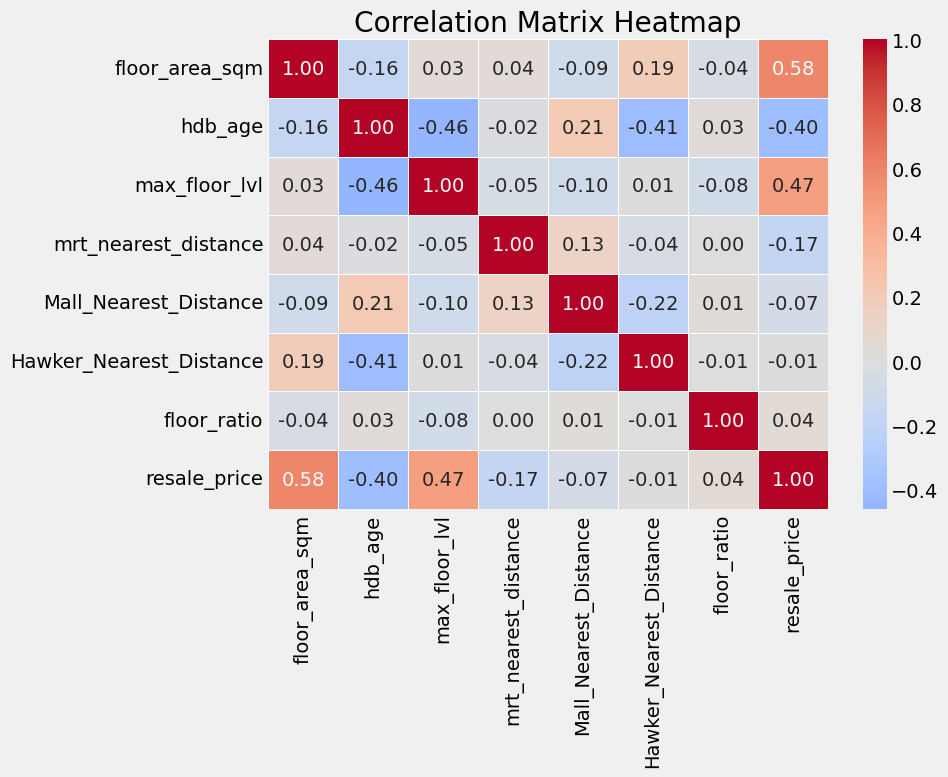

In [13]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, center=0)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [14]:
# Check for highly correlated features (multicollinearity)
# This helps identify features that may be redundant

CORRELATION_THRESHOLD = 0.7  # Features with correlation above this may cause issues

# Get correlation matrix without target
feature_corr = df[NUMERIC_FEATURES + ENGINEERED_FEATURES].corr()

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = abs(feature_corr.iloc[i, j])
        if corr_val > CORRELATION_THRESHOLD:
            high_corr_pairs.append({
                'Feature 1': feature_corr.columns[i],
                'Feature 2': feature_corr.columns[j],
                'Correlation': feature_corr.iloc[i, j]
            })

if high_corr_pairs:
    print(f"⚠️ Highly Correlated Feature Pairs (|r| > {CORRELATION_THRESHOLD}):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\nConsider removing one feature from each pair to reduce multicollinearity.")
else:
    print(f"✓ No feature pairs have correlation above {CORRELATION_THRESHOLD}")

✓ No feature pairs have correlation above 0.7


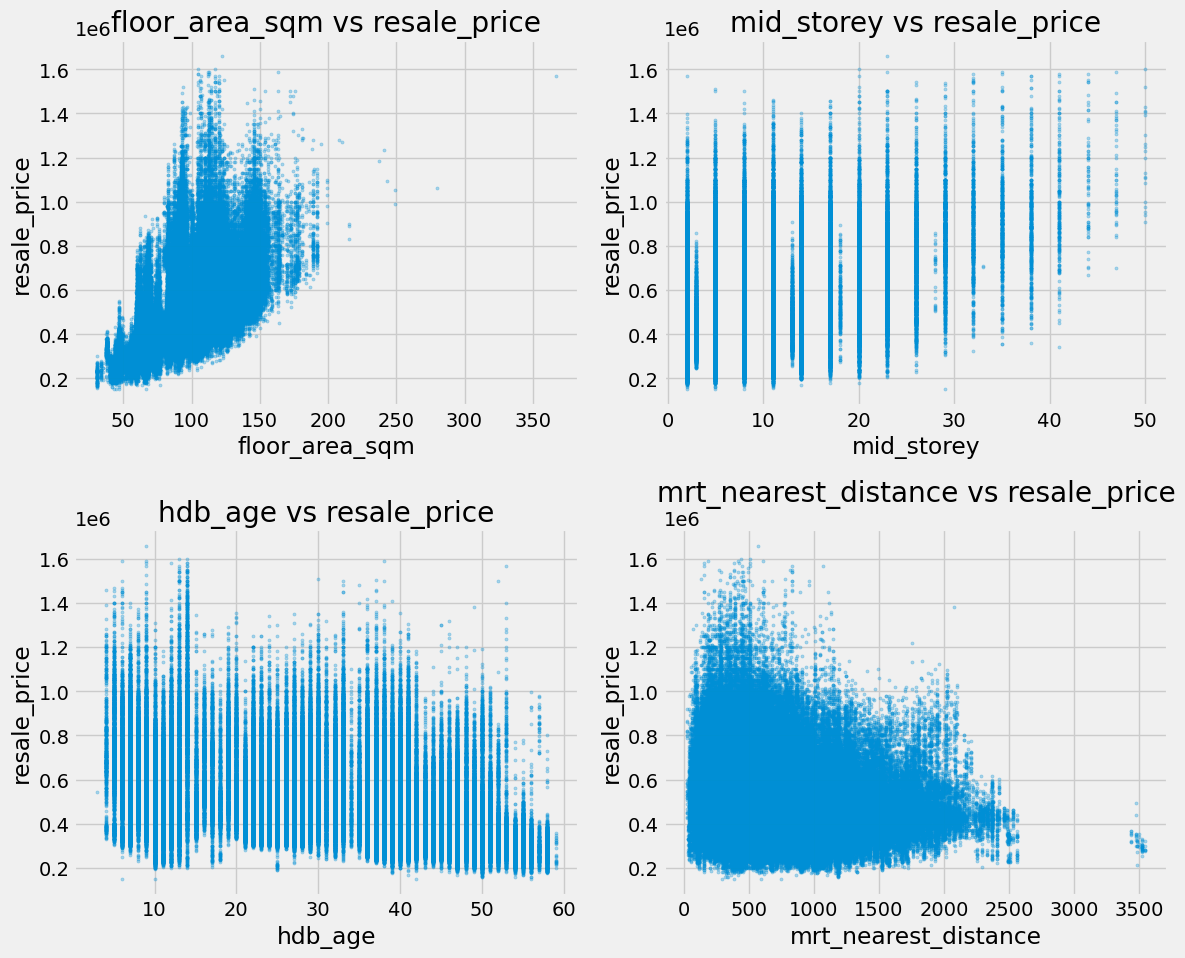

In [15]:
# Scatter plots of top features vs target
top_features = ['floor_area_sqm', 'mid_storey', 'hdb_age', 'mrt_nearest_distance']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df[TARGET_COLUMN], alpha=0.3, s=5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel(TARGET_COLUMN)
    axes[idx].set_title(f'{feature} vs {TARGET_COLUMN}')

plt.tight_layout()
plt.show()

---

## Step 6: Prepare Data for Modeling

Handle missing values and encode categorical variables.

In [16]:
# Create a copy of the dataframe with selected features
model_df = df[ALL_FEATURES + [TARGET_COLUMN]].copy()

# Drop rows with missing values in selected columns
initial_rows = len(model_df)
model_df = model_df.dropna()
print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after cleaning: {len(model_df)}")
print(f"Rows dropped: {initial_rows - len(model_df)}")

Rows before cleaning: 270619
Rows after cleaning: 265409
Rows dropped: 5210


In [17]:
# Encode categorical variables using Label Encoding
# (Tree-based models can handle integer-encoded categoricals)

label_encoders = {}
model_df_encoded = model_df.copy()

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    model_df_encoded[col] = le.fit_transform(model_df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} unique values encoded")

model_df_encoded.head(100)

flat_type: 7 unique values encoded
town: 26 unique values encoded


,floor_area_sqm,hdb_age,max_floor_lvl,mrt_nearest_distance,Mall_Nearest_Distance,Hawker_Nearest_Distance,floor_ratio,flat_type,town,resale_price
0,117.0,47,12,1167.368196,747.338451,335.421442,0.666667,4,0,515000.0
1,73.0,47,12,1194.659204,749.116170,396.305713,0.666667,2,0,368000.0
2,92.0,47,10,1328.501244,932.710381,311.840063,0.800000,3,0,430000.0
3,92.0,47,12,1315.373861,871.544387,418.105609,0.666667,3,0,427000.0
4,67.0,47,12,1396.117062,965.920726,435.091387,0.250000,2,0,323000.0
...,...,...,...,...,...,...,...,...,...,...
95,111.0,22,25,383.610464,221.516377,287.323351,0.720000,4,0,775000.0
96,119.0,45,20,504.801942,52.042132,93.519119,0.400000,4,0,590000.0
97,119.0,45,20,504.801942,52.042132,93.519119,0.400000,4,0,623000.0
98,123.0,40,12,806.045582,1966.362863,724.392862,0.666667,4,1,458000.0


In [39]:
# TO SEE MAPPING OF ENCODED TOWNS BACK TO NAMES (OPTIONAL)
#Get the town encoder
town_encoder = label_encoders['town']

# # Print the mapping: encoded number -> town name
print("Town Encoding Mapping:")
for encoded_value, town_name in enumerate(town_encoder.classes_):
    print(f"  {encoded_value}: {town_name}")



# Create a DataFrame to show the mapping of encoded values to town names
# town_mapping = pd.DataFrame({
#     'encoded': range(len(label_encoders['town'].classes_)),
#     'town': label_encoders['town'].classes_
# })
# print(town_mapping)

Town Encoding Mapping:
  0: ANG MO KIO
  1: BEDOK
  2: BISHAN
  3: BUKIT BATOK
  4: BUKIT MERAH
  5: BUKIT PANJANG
  6: BUKIT TIMAH
  7: CENTRAL AREA
  8: CHOA CHU KANG
  9: CLEMENTI
  10: GEYLANG
  11: HOUGANG
  12: JURONG EAST
  13: JURONG WEST
  14: KALLANG/WHAMPOA
  15: MARINE PARADE
  16: PASIR RIS
  17: PUNGGOL
  18: QUEENSTOWN
  19: SEMBAWANG
  20: SENGKANG
  21: SERANGOON
  22: TAMPINES
  23: TOA PAYOH
  24: WOODLANDS
  25: YISHUN


In [40]:
# Get the flat_type encoder
flat_type_encoder = label_encoders['flat_type']

# Print the mapping: encoded number -> flat_type name
print("Flat Type Encoding Mapping:")
for encoded_value, flat_type_name in enumerate(flat_type_encoder.classes_):
    print(f"  {encoded_value}: {flat_type_name}")

# Create a DataFrame to show the mapping of encoded values to flat_type names
# flat_type_mapping = pd.DataFrame({
#     'encoded': range(len(label_encoders['flat_type'].classes_)),
#     'flat_type': label_encoders['flat_type'].classes_
# })
# print(flat_type_mapping)

Flat Type Encoding Mapping:
  0: 1 ROOM
  1: 2 ROOM
  2: 3 ROOM
  3: 4 ROOM
  4: 5 ROOM
  5: EXECUTIVE
  6: MULTI-GENERATION


---

## Step 7: Split Data into Train and Test Sets

In [19]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

# Prepare features (X) and target (y)
X = model_df_encoded[ALL_FEATURES]
y = model_df_encoded[TARGET_COLUMN]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)} ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set size: {len(X_test)} ({100*TEST_SIZE:.0f}%)")

Training set size: 199056 (75%)
Test set size: 66353 (25%)


---

## Step 8: Define Model Evaluation Function

Create a reusable function to train models and calculate key metrics.

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a model and return evaluation metrics.
    
    Parameters:
    -----------
    model : estimator object
        The model to train and evaluate
    X_train, X_test : DataFrames
        Training and test features
    y_train, y_test : Series
        Training and test targets
    model_name : str
        Name for display purposes
        
    Returns:
    --------
    dict : Dictionary containing model metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R²': metrics.r2_score(y_train, y_train_pred),
        'Test R²': metrics.r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)),
        'fitted_model': model,
        'y_test_pred': y_test_pred
    }
    
    return results

def display_results(results):
    """Display formatted results for a single model."""
    print("=" * 50)
    print(f"MODEL: {results['Model']}")
    print("=" * 50)
    print(f"Train R² Score: {results['Train R²']:.4f}")
    print(f"Test R² Score:  {results['Test R²']:.4f}")
    print()
    print(f"Train RMSE: ${results['Train RMSE']:,.2f}")
    print(f"Test RMSE:  ${results['Test RMSE']:,.2f}")
    print()

---

## Step 9: Train and Evaluate Linear Regression Model (Baseline)

In [21]:
# ========== LINEAR REGRESSION (Baseline) ==========
lr_model = LinearRegression()

# Train and evaluate
lr_results = evaluate_model(lr_model, X_train, X_test, y_train, y_test, 'Linear Regression')
display_results(lr_results)

MODEL: Linear Regression
Train R² Score: 0.6527
Test R² Score:  0.6497

Train RMSE: $103,323.76
Test RMSE:  $103,235.05



In [22]:
# Display Linear Regression coefficients
lr_coef_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Coefficient': lr_results['fitted_model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Coefficients:")
print(f"Intercept: {lr_results['fitted_model'].intercept_:,.2f}")
print("\nFeature Coefficients:")
print(lr_coef_df.to_string(index=False))

Linear Regression Coefficients:
Intercept: 133,883.27

Feature Coefficients:
                Feature  Coefficient
            floor_ratio 63929.986076
              flat_type 17040.072860
          max_floor_lvl  8663.848163
         floor_area_sqm  3722.512165
                hdb_age -3380.573579
                   town -1457.868098
   mrt_nearest_distance   -80.151678
Hawker_Nearest_Distance   -38.161730
  Mall_Nearest_Distance    18.806666


---

## Step 10: Train and Evaluate Random Forest Model

In [23]:
# ========== RANDOM FOREST ==========
# Hyperparameters (modify as needed)
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=15,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    n_jobs=-1                  # Use all CPU cores
)

# Train and evaluate
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
display_results(rf_results)

MODEL: Random Forest
Train R² Score: 0.8816
Test R² Score:  0.8565

Train RMSE: $60,317.65
Test RMSE:  $66,067.74



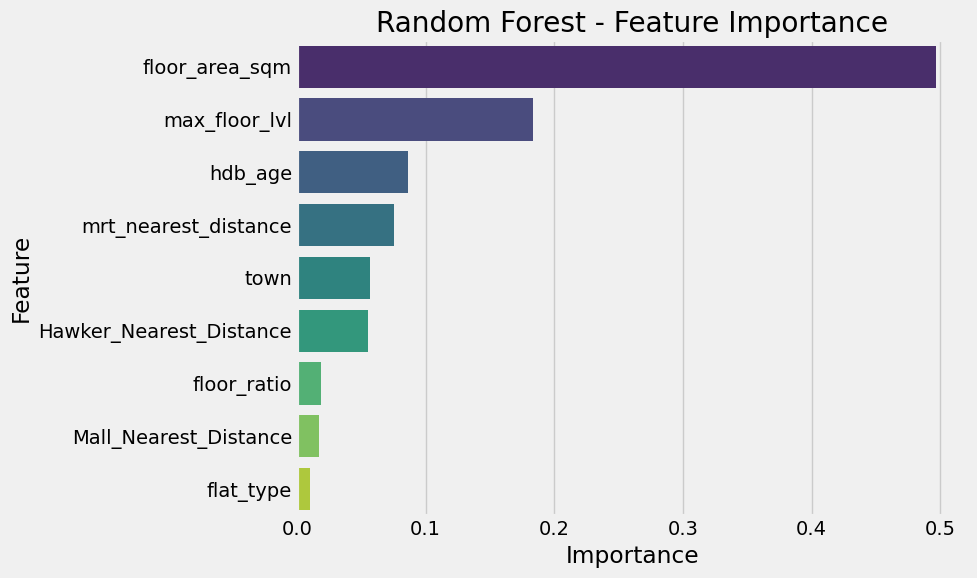

Feature Importance:
                Feature  Importance
         floor_area_sqm    0.496708
          max_floor_lvl    0.183359
                hdb_age    0.086024
   mrt_nearest_distance    0.075641
                   town    0.057063
Hawker_Nearest_Distance    0.055478
            floor_ratio    0.018596
  Mall_Nearest_Distance    0.017266
              flat_type    0.009865


In [24]:
# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))

---

## Step 11: Train and Evaluate LightGBM Model

In [25]:
# ========== LIGHTGBM ==========
# Hyperparameters (modify as needed)
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=15,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    num_leaves=31,             # Maximum number of leaves in one tree
    min_child_samples=20,      # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    verbose=-1                 # Suppress output
)

# Train and evaluate
lgbm_results = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
display_results(lgbm_results)

MODEL: LightGBM
Train R² Score: 0.8350
Test R² Score:  0.8310

Train RMSE: $71,205.53
Test RMSE:  $71,705.78



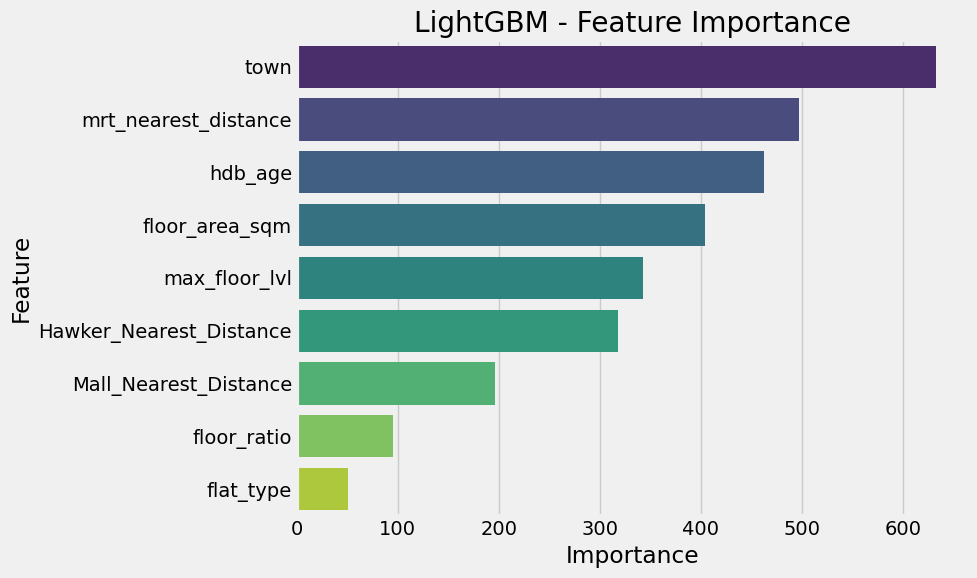

Feature Importance:
                Feature  Importance
                   town         633
   mrt_nearest_distance         497
                hdb_age         463
         floor_area_sqm         404
          max_floor_lvl         343
Hawker_Nearest_Distance         318
  Mall_Nearest_Distance         196
            floor_ratio          95
              flat_type          51


In [26]:
# Feature importance for LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': lgbm_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(lgbm_importance.to_string(index=False))

---

## Step 12: Train and Evaluate XGBoost Model

In [27]:
# ========== XGBOOST ==========
# Hyperparameters (modify as needed)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=10,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    min_child_weight=5,        # Minimum sum of instance weight in a child
    subsample=0.8,             # Subsample ratio of training instances
    colsample_bytree=0.8,      # Subsample ratio of columns
    random_state=RANDOM_STATE,
    verbosity=0                # Suppress output
)

# Train and evaluate
xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')
display_results(xgb_results)

MODEL: XGBoost
Train R² Score: 0.8859
Test R² Score:  0.8642

Train RMSE: $59,218.81
Test RMSE:  $64,285.89



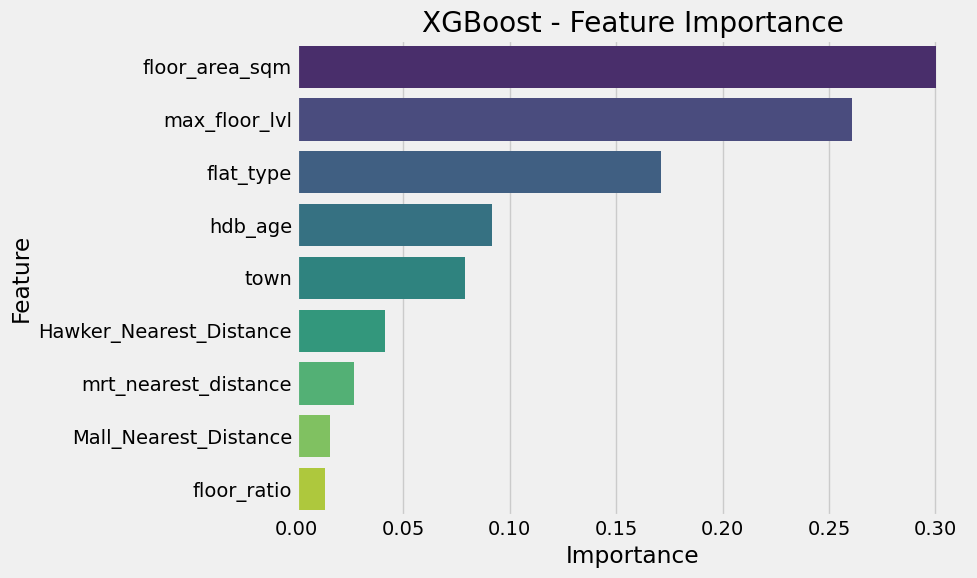

Feature Importance:
                Feature  Importance
         floor_area_sqm    0.300289
          max_floor_lvl    0.260865
              flat_type    0.171248
                hdb_age    0.091626
                   town    0.079161
Hawker_Nearest_Distance    0.041493
   mrt_nearest_distance    0.026944
  Mall_Nearest_Distance    0.015404
            floor_ratio    0.012970


In [28]:
# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': xgb_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(xgb_importance.to_string(index=False))

---

## Step 13: Train and Evaluate CatBoost Model

In [29]:
# ========== CATBOOST ==========
# Hyperparameters (modify as needed)
catboost_model = CatBoostRegressor(
    iterations=100,            # Number of boosting iterations
    depth=10,                  # Depth of the tree
    learning_rate=0.1,         # Learning rate
    l2_leaf_reg=3,             # L2 regularization coefficient
    random_state=RANDOM_STATE,
    verbose=0                  # Suppress output
)

# Train and evaluate
catboost_results = evaluate_model(catboost_model, X_train, X_test, y_train, y_test, 'CatBoost')
display_results(catboost_results)

MODEL: CatBoost
Train R² Score: 0.8353
Test R² Score:  0.8313

Train RMSE: $71,150.78
Test RMSE:  $71,642.29



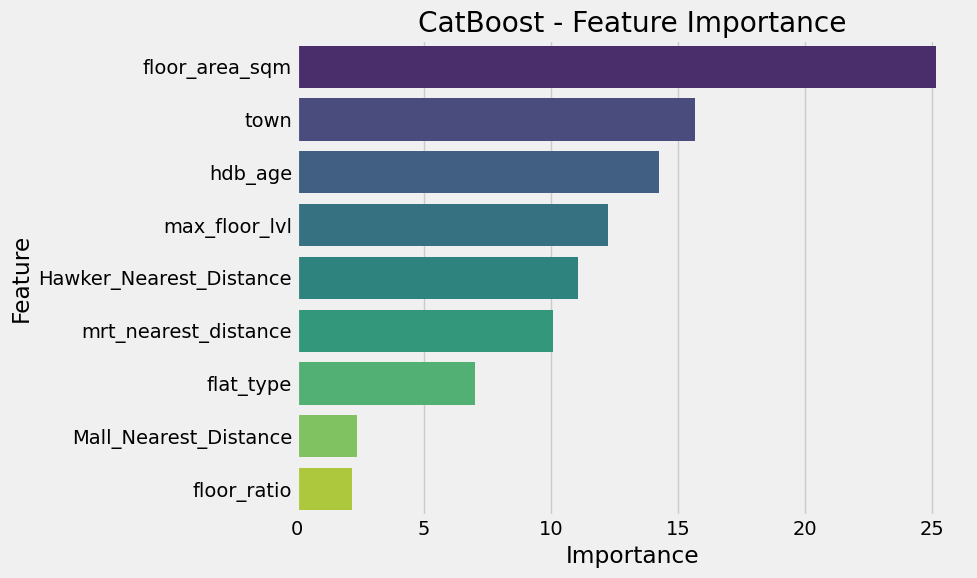

Feature Importance:
                Feature  Importance
         floor_area_sqm   25.152602
                   town   15.660743
                hdb_age   14.266597
          max_floor_lvl   12.257181
Hawker_Nearest_Distance   11.070895
   mrt_nearest_distance   10.096701
              flat_type    6.998428
  Mall_Nearest_Distance    2.346786
            floor_ratio    2.150067


In [30]:
# Feature importance for CatBoost
catboost_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': catboost_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(catboost_importance.to_string(index=False))

---

## Step 14: Model Comparison Summary Table

Compare the performance of all five models side-by-side.

In [31]:
# Collect results from all models (including Linear Regression baseline)
all_results = [lr_results, rf_results, lgbm_results, xgb_results, catboost_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train R²': round(r['Train R²'], 4),
        'Test R²': round(r['Test R²'], 4),
        'Train RMSE': round(r['Train RMSE'], 2),
        'Test RMSE': round(r['Test RMSE'], 2)
    }
    for r in all_results
])

# Sort by Test R² (best performance first)
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON SUMMARY (5 Models)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)

MODEL COMPARISON SUMMARY (5 Models)
            Model  Train R²  Test R²  Train RMSE  Test RMSE
          XGBoost    0.8859   0.8642    59218.81   64285.89
    Random Forest    0.8816   0.8565    60317.65   66067.74
         CatBoost    0.8353   0.8313    71150.78   71642.29
         LightGBM    0.8350   0.8310    71205.53   71705.78
Linear Regression    0.6527   0.6497   103323.76  103235.05



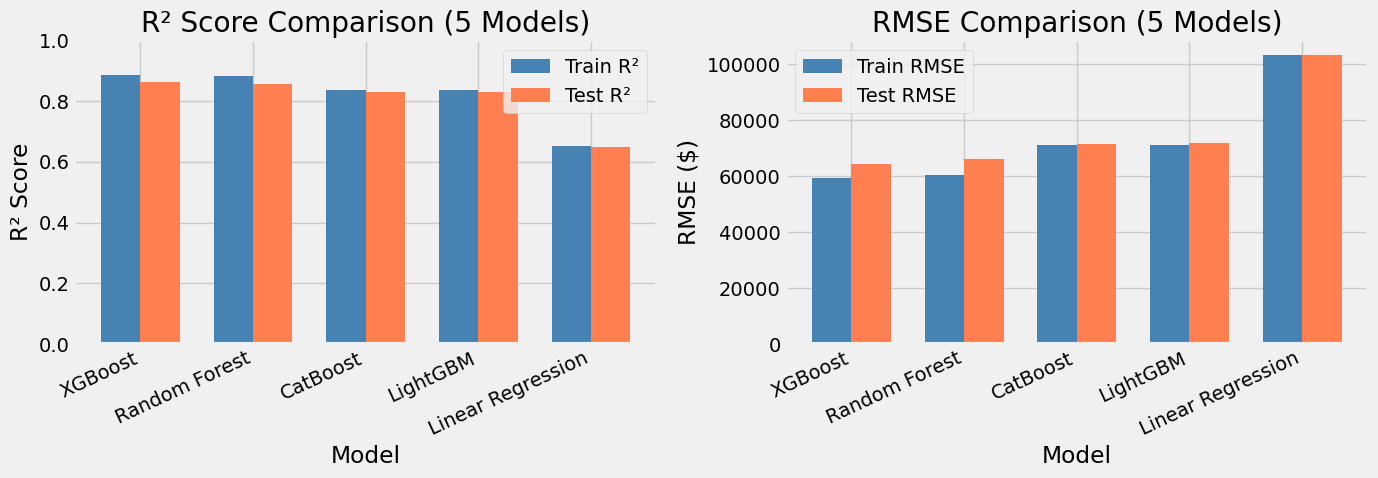

In [32]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Train R²'], width, label='Train R²', color='steelblue')
axes[0].bar(x + width/2, comparison_df['Test R²'], width, label='Test R²', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison (5 Models)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)

# RMSE comparison
axes[1].bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', color='steelblue')
axes[1].bar(x + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', color='coral')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE Comparison (5 Models)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
# Identify best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model = comparison_df.loc[best_model_idx]

print("\n" + "*" * 50)
print("BEST PERFORMING MODEL")
print("*" * 50)
print(f"Model: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.4f}")
print(f"Test RMSE: ${best_model['Test RMSE']:,.2f}")
print("*" * 50)


**************************************************
BEST PERFORMING MODEL
**************************************************
Model: XGBoost
Test R²: 0.8642
Test RMSE: $64,285.89
**************************************************


---

## Step 15: Prediction vs Actual Visualization

Visualize how well each model's predictions match the actual values.

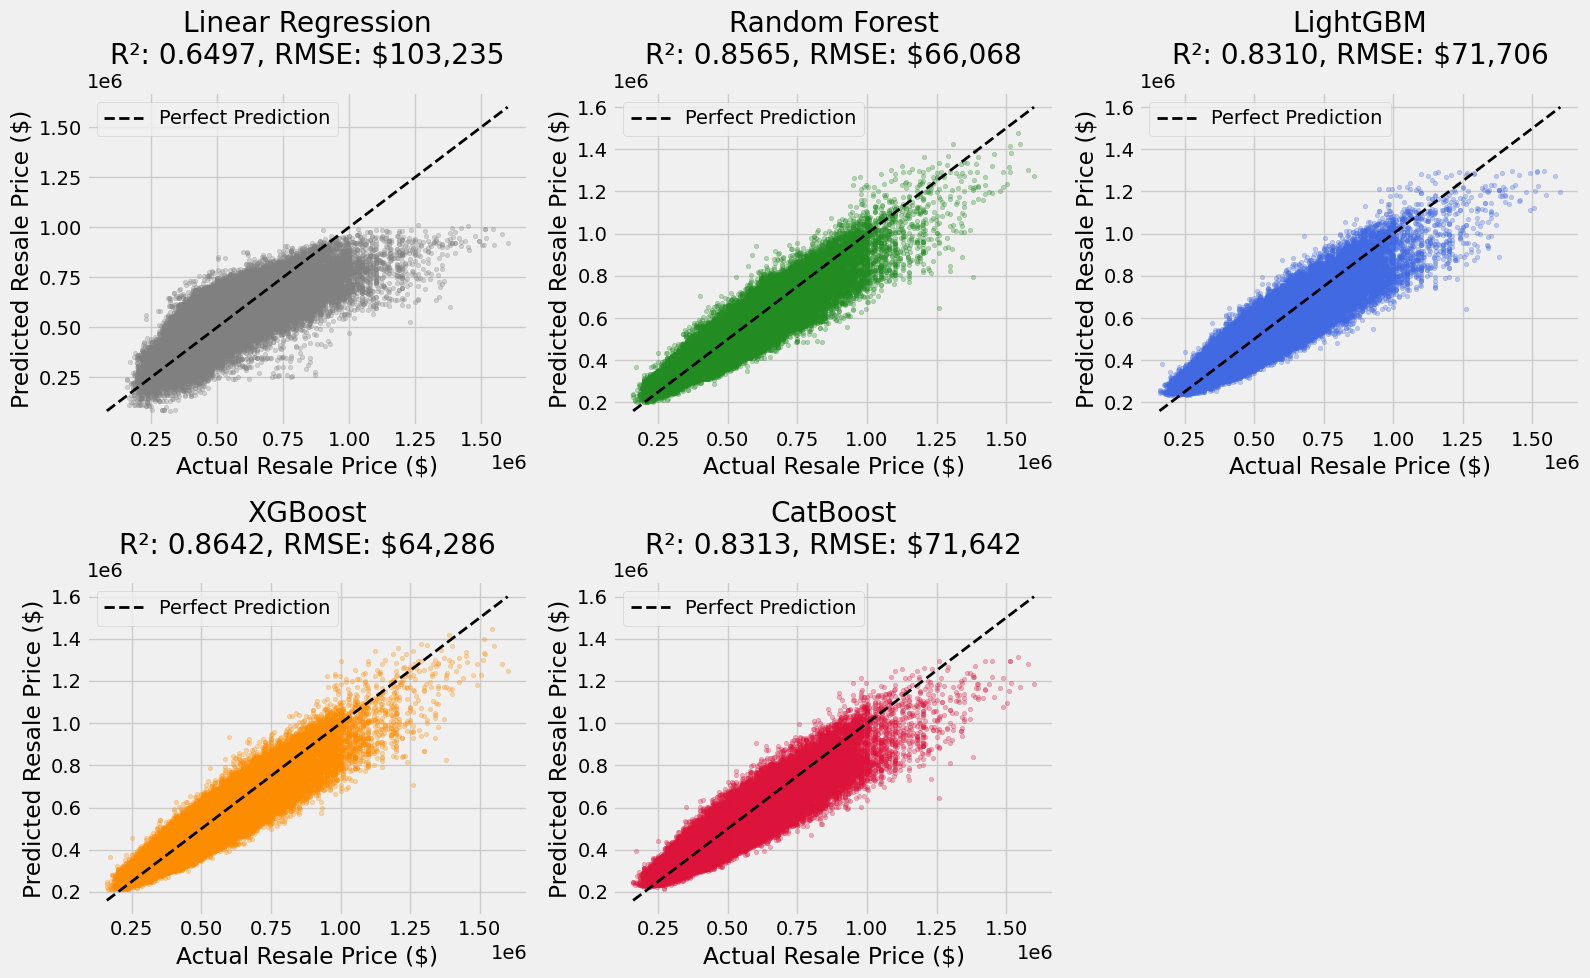

In [34]:
# Create prediction vs actual plots for all 5 models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['gray', 'forestgreen', 'royalblue', 'darkorange', 'crimson']

for idx, (results, color) in enumerate(zip(all_results, colors)):
    ax = axes[idx]
    y_pred = results['y_test_pred']
    
    # Scatter plot of actual vs predicted
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, c=color)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Resale Price ($)')
    ax.set_ylabel('Predicted Resale Price ($)')
    ax.set_title(f"{results['Model']}\nR²: {results['Test R²']:.4f}, RMSE: ${results['Test RMSE']:,.0f}")
    ax.legend()

# Hide the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

---

## Summary Checklist

- [ ] **Step 0:** Installed required packages (lightgbm, xgboost, catboost)
- [ ] **Step 1:** Identified target variable (`resale_price`)
- [ ] **Step 2:** Imported packages and loaded data
- [ ] **Step 3:** Explored dataset structure
- [ ] **Step 4:** Selected features for modeling
- [ ] **Step 5:** Analyzed feature correlations
- [ ] **Step 6:** Prepared data (handled missing values, encoded categoricals)
- [ ] **Step 7:** Split data into train/test sets
- [ ] **Step 8:** Defined model evaluation function
- [ ] **Step 9:** Trained Linear Regression model (Baseline)
- [ ] **Step 10:** Trained Random Forest model
- [ ] **Step 11:** Trained LightGBM model
- [ ] **Step 12:** Trained XGBoost model
- [ ] **Step 13:** Trained CatBoost model
- [ ] **Step 14:** Compared all 5 models (R² and RMSE)
- [ ] **Step 15:** Visualized predictions vs actuals